***Data Collection & Preparation***

Combined three datasets from multiple sources into one unified dataframe

Cleaned the text data by removing null values, duplicates, and extra whitespace

In [ ]:
#LOAD
import pandas as pd

#ISOT
isot_true = pd.read_csv('True.csv')
isot_fake = pd.read_csv('Fake.csv')

isot_true['label'] = 1
isot_fake['label'] = 0

isot_data = pd.concat([isot_true, isot_fake], axis=0)
isot_data = isot_data[['text', 'label']]

In [ ]:
print(len(isot_data))
print(isot_data['label'].value_counts())

44898
label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
isot_data.isnull().sum()

,0
text,0
label,0


In [ ]:
isot_data.head()

,text,label
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [ ]:
#LIAR
liar_cols = ['id', 'label_raw', 'statement', 'subject', 'speaker', 'job', 'state', 'party', 'barely_true', 'false', 'half_true', 'mostly_true', 'pants_on_fire', 'context']

l_train = pd.read_csv('train.tsv', sep='\t', names=liar_cols)
l_test = pd.read_csv('test.tsv', sep='\t', names=liar_cols)
l_valid = pd.read_csv('valid.tsv', sep='\t', names=liar_cols)

liar_data = pd.concat([l_train, l_test, l_valid], axis=0)

label_map = {
    'true': 1, 'mostly-true': 1, 'half-true': 1,
    'false': 0, 'barely-true': 0, 'pants-fire': 0}

liar_data['label'] = liar_data['label_raw'].map(label_map)
liar_data = liar_data[['statement', 'label']].rename(columns={'statement': 'text'})

In [ ]:
liar_data.head()

,text,label
0,Says the Annies List political group supports ...,0
1,When did the decline of coal start? It started...,1
2,"Hillary Clinton agrees with John McCain ""by vo...",1
3,Health care reform legislation is likely to ma...,0
4,The economic turnaround started at the end of ...,1


In [ ]:
print(liar_data['label'].value_counts())
print(len(liar_data))
print(liar_data.isnull().sum())

label
1    7134
0    5657
Name: count, dtype: int64
12791
text     0
label    0
dtype: int64


In [ ]:
#WELFake
welfake = pd.read_csv('WELFake_Dataset.csv')
welfake = welfake[['text', 'label']]
welfake.head()

,text,label
0,No comment is expected from Barack Obama Membe...,1
1,Did they post their votes for Hillary already?,1
2,"Now, most of the demonstrators gathered last ...",1
3,A dozen politically active pastors came here f...,0
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
print(welfake['label'].value_counts())
print(len(welfake))
print(welfake.isnull().sum())

label
1    37106
0    35028
Name: count, dtype: int64
72134
text     39
label     0
dtype: int64


In [ ]:
welfake[welfake.isnull().any(axis=1)]

,text,label
2457,NaN,1
3534,NaN,1
3709,NaN,1
5612,NaN,1
6270,NaN,1
6997,NaN,1
7083,NaN,1
8974,NaN,1
16717,NaN,1
17781,NaN,1


In [ ]:
welfake = welfake.dropna()

print(welfake.isnull().sum())

text     0
label    0
dtype: int64


In [ ]:
welfake.head()

,text,label
0,No comment is expected from Barack Obama Membe...,1
1,Did they post their votes for Hillary already?,1
2,"Now, most of the demonstrators gathered last ...",1
3,A dozen politically active pastors came here f...,0
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
# CONCATENATE 3 DATASETS
final_df = pd.concat([isot_data, liar_data, welfake], axis=0)

print(final_df.shape[0])
print(final_df['label'].value_counts())

129784
label
1    65618
0    64166
Name: count, dtype: int64


In [ ]:
pip install nltk

***Text Cleaning***

In [ ]:
final_df.isnull().sum()

,0
text,0
label,0


In [ ]:
(final_df["text"].str.strip() == "").sum()

np.int64(1375)

In [ ]:
#remove actual NaN
final_df = final_df.dropna(subset=["text", "label"])

#сonvert to string
final_df["text"] = final_df["text"].astype(str)

#remove empty/whitespace-only rows
final_df = final_df[final_df["text"].str.strip() != ""]
#reset index
final_df = final_df.reset_index(drop=True)

print(final_df.shape[0])
print(final_df['label'].value_counts())

128409
label
1    64874
0    63535
Name: count, dtype: int64


In [ ]:
# Preprocessing
import re
import string
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

In [ ]:
# remove duplicates
duplicate_rows = final_df[final_df.duplicated(subset=['text'], keep=False)]
print(final_df.duplicated(subset=['text']).sum())

display(duplicate_rows.sort_values(by='text').head(10))

52929


,text,label
85496,"\n\n \nIf Clinton is elected, Obama will hand ...",1
90214,"\n\n \nIf Clinton is elected, Obama will hand ...",1
73298,"\n\n \nIn the past 24 hours, some very stunnin...",1
81429,"\n\n \nIn the past 24 hours, some very stunnin...",1
76836,\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER ...,1
69587,\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER ...,1
58317,\n\n \nUPDATE: HILLARY CLINTON IS AGAIN UNDER ...,1
85112,\n\nCNN finally made it public that they have ...,1
81392,\n\nCNN finally made it public that they have ...,1
95104,\n\nIn the effort to prove the credibility of ...,1


In [ ]:
all_duplicates = final_df[final_df.duplicated(subset=['text'], keep=False)]
all_duplicates_sorted = all_duplicates.sort_values(by='text')

all_duplicates_sorted.to_csv('ALL_DUPLICATES_CHECK.tsv', index=False)

In [ ]:
final_df = final_df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(final_df)

                                                    text  label
0      WASHINGTON (Reuters) - The head of a conservat...      1
1      WASHINGTON (Reuters) - Transgender people will...      1
2      WASHINGTON (Reuters) - The special counsel inv...      1
3      WASHINGTON (Reuters) - Trump campaign adviser ...      1
4      SEATTLE/WASHINGTON (Reuters) - President Donal...      1
...                                                  ...    ...
75475  BRUSSELS  —   Six weeks before a critical summ...      0
75476  (Want to get this briefing by email? Here’s th...      0
75477  PARIS  —   In the age of Donald J. Trump, “Bre...      0
75478  The flag at Desert Hot Springs' Condor Gun Sho...      0
75479  Migrants Refuse To Leave Train At Refugee Camp...      0

[75480 rows x 2 columns]


***Feature Engineering***

In [ ]:
# Feature Engineering
def extract_stylometry(df):
    # 1. Caps Lock
    df['caps_ratio'] = df['text'].apply(lambda x: len([w for w in str(x).split() if w.isupper()]) / (len(str(x).split()) + 1))

    # 2.!
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))

    # 3.УЗЫНДЫК
    df['text_len'] = df['text'].apply(lambda x: len(str(x)))

    # 4.?
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))

    return df

eda_df = extract_stylometry(final_df)
display(eda_df)

,text,label,caps_ratio,exclamation_count,text_len,question_count
0,WASHINGTON (Reuters) - The head of a conservat...,1,0.016000,0,4659,0
1,WASHINGTON (Reuters) - Transgender people will...,1,0.011200,0,4077,0
2,WASHINGTON (Reuters) - The special counsel inv...,1,0.015284,0,2789,0
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1,0.010610,0,2461,0
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1,0.017585,1,5204,1
...,...,...,...,...,...,...
75475,BRUSSELS — Six weeks before a critical summ...,0,0.020570,0,7794,0
75476,(Want to get this briefing by email? Here’s th...,0,0.012640,0,4201,4
75477,"PARIS — In the age of Donald J. Trump, “Bre...",0,0.005742,3,7229,1
75478,The flag at Desert Hot Springs' Condor Gun Sho...,0,0.010143,0,13017,1


In [ ]:
import nltk

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [ ]:
import unicodedata
from nltk.tokenize import word_tokenize

def absolute_cleaning_pipeline(text):
    #Unicode & Encoding Normalization
    text = unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode('utf-8')

    #HTML & URL REMOVING
    text = re.sub(r'https?://\S+|www\.\S+|<.*?>+', '', text)

    #REMOVING Reuters/CNN/BBC patterns via regex
    text = re.sub(r'^.*?\(reuters\)\s*[-—]\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^.*?\(cnn\)\s*[-—]\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^.*?\(bbc\)\s*[-—]\s*', '', text, flags=re.IGNORECASE)

    #Text Normalization(lowercase & punctuation & numbers)
    text = text.lower()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)

    #Advanced Tokenization
    tokens = word_tokenize(text)

    #Stopword Removal & Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return " ".join(cleaned_tokens)

final_df['clean_text'] = final_df['text'].apply(absolute_cleaning_pipeline)

<>:19: SyntaxWarning: invalid escape sequence '\w'
<>:19: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_4008/2924163666.py:19: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [ ]:
final_df

,text,label,caps_ratio,exclamation_count,text_len,question_count,clean_text
0,WASHINGTON (Reuters) - The head of a conservat...,1,0.016000,0,4659,0,head conservative republican faction congress ...
1,WASHINGTON (Reuters) - Transgender people will...,1,0.011200,0,4077,0,transgender people allowed first time enlist m...
2,WASHINGTON (Reuters) - The special counsel inv...,1,0.015284,0,2789,0,special counsel investigation link russia pres...
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1,0.010610,0,2461,0,trump campaign adviser george papadopoulos tol...
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1,0.017585,1,5204,1,president donald trump called postal service f...
...,...,...,...,...,...,...,...
75475,BRUSSELS — Six weeks before a critical summ...,0,0.020570,0,7794,0,brussels six week critical summit meeting aime...
75476,(Want to get this briefing by email? Here’s th...,0,0.012640,0,4201,4,want get briefing email here good evening here...
75477,"PARIS — In the age of Donald J. Trump, “Bre...",0,0.005742,3,7229,1,paris age donald trump brexit resurgent french...
75478,The flag at Desert Hot Springs' Condor Gun Sho...,0,0.010143,0,13017,1,flag desert hot spring condor gun shop flew ha...


In [ ]:
from collections import Counter

#count frequency
word_freq = Counter()
for text in final_df['clean_text']:
    word_freq.update(str(text).split())

#rare words
rare_words = {word for word, count in word_freq.items() if count <= 5}

#remove rare words
final_df['clean_text'] = final_df['clean_text'].apply(lambda x: ' '.join([w for w in str(x).split() if w not in rare_words]))

print(f"Rare Word Filtering {len(rare_words)}")

Rare Word Filtering 201683


In [ ]:
final_df.duplicated().sum()

np.int64(0)

In [ ]:
pip install seaborn

***Research & Data Analysis (EDA)***

- Class Distribution (Balance)

- Word Count, Text Length and Caps Words Analysis

- Sentence Type Analysis

- Top 10 Words in Real/ Fake News

In [ ]:
# DATASET OVERVIEW

print("Dataset Shape:")
print(final_df.shape)

print("\nColumn Names:")
print(final_df.columns)

print("\nData Types:")
print(final_df.dtypes)

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nFirst 5 Rows:")
display(final_df.head())

print("\nClass Distribution:")
print(final_df['label'].value_counts())

print("\nStatistical Summary:")
display(final_df.describe())

Dataset Shape:
(62129, 7)

Column Names:
Index(['text', 'label', 'caps_ratio', 'exclamation_count', 'text_len',
       'question_count', 'clean_text'],
      dtype='object')

Data Types:
text                  object
label                float64
caps_ratio           float64
exclamation_count      int64
text_len               int64
question_count         int64
clean_text            object
dtype: object

Missing Values:
text                 0
label                0
caps_ratio           0
exclamation_count    0
text_len             0
question_count       0
clean_text           0
dtype: int64

First 5 Rows:


,text,label,caps_ratio,exclamation_count,text_len,question_count,clean_text
0,WASHINGTON (Reuters) - The head of a conservat...,1.0,0.016000,0,4659,0,head conservative republican faction congress ...
1,WASHINGTON (Reuters) - Transgender people will...,1.0,0.011200,0,4077,0,transgender people allowed first time enlist m...
2,WASHINGTON (Reuters) - The special counsel inv...,1.0,0.015284,0,2789,0,special counsel investigation link russia pres...
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1.0,0.010610,0,2461,0,trump campaign adviser george papadopoulos tol...
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1.0,0.017585,1,5204,1,president donald trump called postal service f...



Class Distribution:
label
1.0    33428
0.0    28701
Name: count, dtype: int64

Statistical Summary:


,label,caps_ratio,exclamation_count,text_len,question_count
count,62129.000000,62129.000000,62129.000000,62129.000000,62129.000000
mean,0.538042,0.019454,0.331456,2365.491268,0.637110
std,0.498555,0.034366,1.687529,3023.621760,2.338239
min,0.000000,0.000000,0.000000,3.000000,0.000000
25%,0.000000,0.004228,0.000000,418.000000,0.000000
50%,1.000000,0.012857,0.000000,1935.000000,0.000000
75%,1.000000,0.024490,0.000000,3110.000000,0.000000
max,1.000000,0.964286,143.000000,142961.000000,159.000000


In [ ]:
# CLASS DISTRIBUTION

import plotly.express as px

fig = px.histogram(
    final_df,
    x='label',
    color='label',
    text_auto=True,
    title='Distribution of Fake and Real News'
)

fig.update_layout(
    xaxis_title='Label',
    yaxis_title='Count'
)

fig.show()

In [ ]:
# PIE CHART

label_counts =final_df['label'].value_counts()

fig = px.pie(
    values=label_counts.values,
    names=['Real', 'Fake'],
    title='Fake vs Real News Ratio'
)

fig.show()

In [ ]:
# CREATE EXTRA FEATURES

import numpy as np

# text length
final_df['text_length'] = final_df['clean_text'].apply(len)

# word count
final_df['word_count'] = final_df['clean_text'].apply(
    lambda x: len(x.split())
)

# average word length
final_df['avg_word_length'] = final_df['clean_text'].apply(
    lambda x: np.mean([len(word) for word in x.split()])
    if len(x.split()) > 0 else 0
)

# number count
final_df['number_count'] = final_df['text'].apply(
    lambda x: len(re.findall(r'\d+', x))
)

display(final_df.head())

,text,label,caps_ratio,exclamation_count,text_len,question_count,clean_text,text_length,word_count,avg_word_length,number_count
0,WASHINGTON (Reuters) - The head of a conservat...,1.0,0.016000,0,4659,0,head conservative republican faction congress ...,3241,433,6.487298,17
1,WASHINGTON (Reuters) - Transgender people will...,1.0,0.011200,0,4077,0,transgender people allowed first time enlist m...,2918,365,6.997260,9
2,WASHINGTON (Reuters) - The special counsel inv...,1.0,0.015284,0,2789,0,special counsel investigation link russia pres...,1910,256,6.464844,2
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1.0,0.010610,0,2461,0,trump campaign adviser george papadopoulos tol...,1741,222,6.846847,3
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1.0,0.017585,1,5204,1,president donald trump called postal service f...,3458,470,6.359574,34


In [ ]:
# TEXT LENGTH DISTRIBUTION

fig = px.histogram(
    final_df,
    x='text_length',
    color='label',
    nbins=60,
    marginal='box',
    title='Text Length Distribution'
)

fig.update_layout(
    xaxis_title='Text Length',
    yaxis_title='Frequency'
)

fig.show()

In [ ]:
# WORD COUNT DISTRIBUTION

fig = px.box(
    final_df,
    x='label',
    y='word_count',
    color='label',
    title='Word Count by Class'
)

fig.show()

In [ ]:
# VIOLIN PLOT

fig = px.violin(
    final_df,
    x='label',
    y='text_length',
    color='label',
    box=True,
    title='Text Length Distribution by Class'
)

fig.show()

In [ ]:
# CAPS RATIO DISTRIBUTION

fig = px.box(
    final_df,
    x='label',
    y='caps_ratio',
    color='label',
    title='Capital Letter Ratio Distribution'
)

fig.show()

In [ ]:
# EXCLAMATION MARK ANALYSIS

fig = px.box(
    final_df,
    x='label',
    y='exclamation_count',
    color='label',
    title='Exclamation Mark Distribution'
)

fig.show()

In [ ]:
# QUESTION MARK ANALYSIS

fig = px.box(
    final_df,
    x='label',
    y='question_count',
    color='label',
    title='Question Mark Distribution'
)

fig.show()

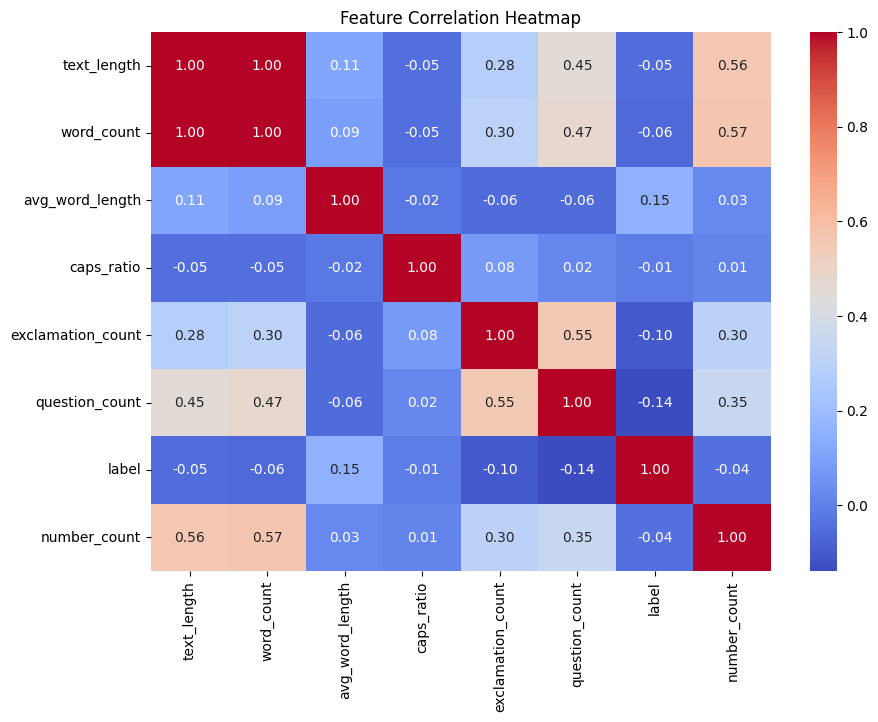

In [ ]:
# CORRELATION HEATMAP

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'text_length',
    'word_count',
    'avg_word_length',
    'caps_ratio',
    'exclamation_count',
    'question_count',
    'label',
    'number_count'
]

corr = final_df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
# TOP WORDS IN FAKE NEWS

from collections import Counter
import pandas as pd

fake_words = ' '.join(
    final_df[final_df['label'] == 0]['clean_text']
).split()

counter = Counter(fake_words)

top_fake = counter.most_common(20)

fake_df = pd.DataFrame(
    top_fake,
    columns=['Word', 'Count']
)

fig = px.bar(
    fake_df,
    x='Count',
    y='Word',
    orientation='h',
    title='Top 20 Words in Fake News'
)

fig.show()

In [ ]:
# TOP WORDS IN REAL NEWS

real_words = ' '.join(
    final_df[final_df['label'] == 1]['clean_text']
).split()

counter = Counter(real_words)

top_real = counter.most_common(20)

real_df = pd.DataFrame(
    top_real,
    columns=['Word', 'Count']
)

fig = px.bar(
    real_df,
    x='Count',
    y='Word',
    orientation='h',
    title='Top 20 Words in Real News'
)

fig.show()

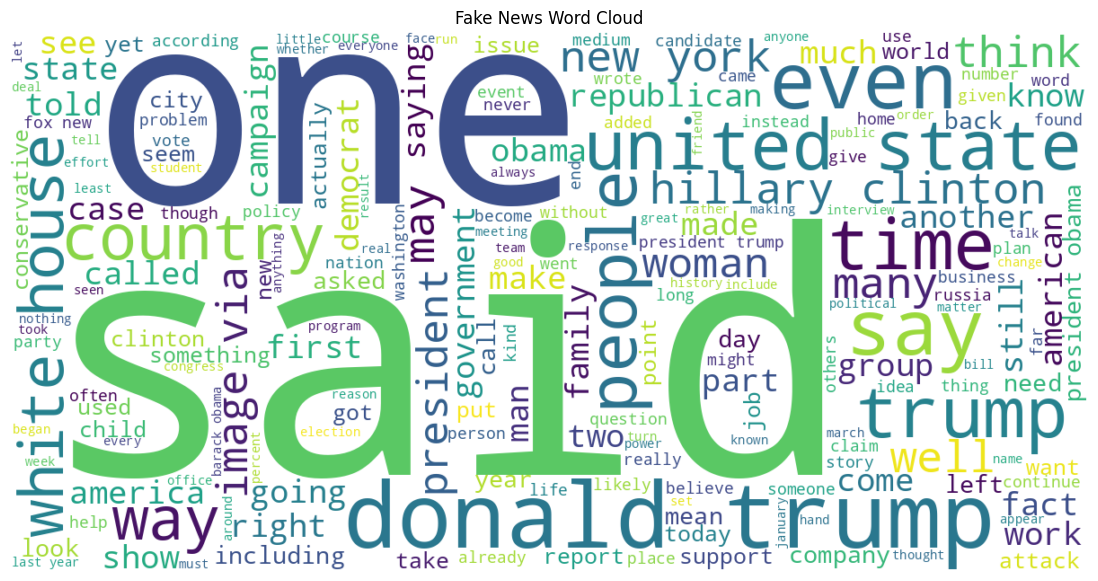

In [ ]:
# FAKE NEWS WORD CLOUD

from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(
    final_df[final_df['label'] == 0]['clean_text']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Fake News Word Cloud")

plt.show()

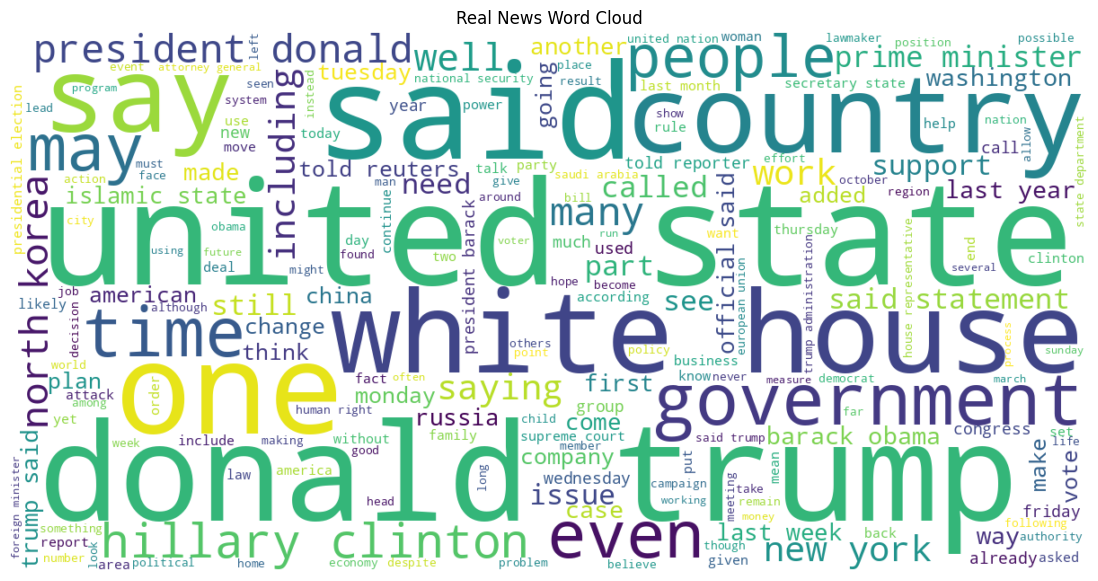

In [ ]:
# REAL NEWS WORD CLOUD

real_text = ' '.join(
    final_df[final_df['label'] == 1]['clean_text']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Real News Word Cloud")

plt.show()

In [ ]:
# BIGRAM ANALYSIS

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, ngram_range=(2,2), n=15):

    vec = CountVectorizer(
        ngram_range=ngram_range
    )

    bow = vec.fit_transform(corpus)

    words = vec.get_feature_names_out()

    sum_words = bow.sum(axis=0)

    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    words_freq = sorted(
        words_freq,
        key=lambda x: x[1],
        reverse=True
    )

    return words_freq[:n]

fake_bigrams = get_top_ngrams(
    final_df[final_df['label'] == 0]['clean_text']
)

bigram_df = pd.DataFrame(
    fake_bigrams,
    columns=['Bigram', 'Count']
)

fig = px.bar(
    bigram_df,
    x='Count',
    y='Bigram',
    orientation='h',
    title='Top Fake News Bigrams'
)

fig.show()

In [ ]:
# TRIGRAM ANALYSIS

fake_trigrams = get_top_ngrams(
    final_df[final_df['label'] == 0]['clean_text'],
    ngram_range=(3,3)
)

trigram_df = pd.DataFrame(
    fake_trigrams,
    columns=['Trigram', 'Count']
)

fig = px.bar(
    trigram_df,
    x='Count',
    y='Trigram',
    orientation='h',
    title='Top Fake News Trigrams'
)

fig.show()

In [ ]:
# SUMMARY STATISTICS

summary_stats = final_df.groupby('label')[
    [
        'text_length',
        'word_count',
        'avg_word_length',
        'caps_ratio',
        'exclamation_count',
        'question_count'
    ]
].mean()

display(summary_stats)

,text_length,word_count,avg_word_length,caps_ratio,exclamation_count,question_count
label,,,,,,
0,2038.801117,279.911702,6.225614,0.018640,0.468788,1.033841
1,1576.304318,212.444476,6.355518,0.019808,0.272436,0.526620


In [ ]:
# SENTIMENT ANALYSIS

from textblob import TextBlob

final_df['sentiment'] = final_df['clean_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

fig = px.histogram(
    final_df,
    x='sentiment',
    color='label',
    nbins=50,
    title='Sentiment Distribution'
)

fig.show()

***Machine Learning Experiments***

- Applied TF-IDF vectorization
- Trained multiple models:
  Logistic Regression, Multinomial Vaive Bayes, Random Forest, SVM, and XGBoost
- Evaluated model performance using Accuracy, Precision, Recall, and F1-score
- Performed hyperparameter tuning for SVM and XGBoost models using RandomizedSearchCV


In [ ]:
# Import Libraries

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

X = final_df['clean_text'].astype(str)
y = final_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(49703, 5000)
(12426, 5000)


In [ ]:
# LOGISTIC REGRESSION MODEL

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

# Train using TF-IDF vectors
lr_model.fit(X_train_tfidf, y_train)

# Predict
lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [ ]:
# LOGISTIC REGRESSION METRICS

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy :", lr_accuracy)

print("Precision:", lr_precision)

print("Recall   :", lr_recall)

print("F1 Score :", lr_f1)

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

Accuracy : 0.8245614035087719
Precision: 0.8246397694524495
Recall   : 0.8559676936883039
F1 Score : 0.840011742257449

Classification Report:

              precision    recall  f1-score   support

         0.0       0.82      0.79      0.81      5740
         1.0       0.82      0.86      0.84      6686

    accuracy                           0.82     12426
   macro avg       0.82      0.82      0.82     12426
weighted avg       0.82      0.82      0.82     12426



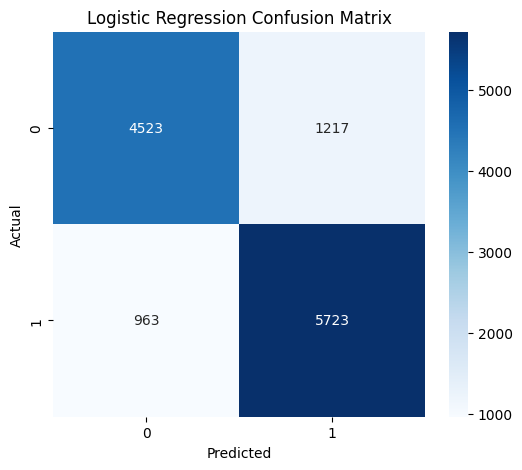

In [ ]:
# LOGISTIC REGRESSION CONFUSION MATRIX

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# MULTINOMIAL NAIVE BAYES MODEL

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

# Train on TF-IDF features
nb_model.fit(X_train_tfidf, y_train)

# Predict
nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Training Complete")

Naive Bayes Training Complete


In [ ]:
# NAIVE BAYES METRICS

nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(y_test, nb_pred)

nb_recall = recall_score(y_test, nb_pred)

nb_f1 = f1_score(y_test, nb_pred)

print("Accuracy :", nb_accuracy)

print("Precision:", nb_precision)

print("Recall   :", nb_recall)

print("F1 Score :", nb_f1)

print("\nClassification Report:\n")

print(classification_report(y_test, nb_pred))

Accuracy : 0.7662964751327861
Precision: 0.7892321810951362
Recall   : 0.7717618905174992
F1 Score : 0.7803992740471869

Classification Report:

              precision    recall  f1-score   support

         0.0       0.74      0.76      0.75      5740
         1.0       0.79      0.77      0.78      6686

    accuracy                           0.77     12426
   macro avg       0.77      0.77      0.77     12426
weighted avg       0.77      0.77      0.77     12426



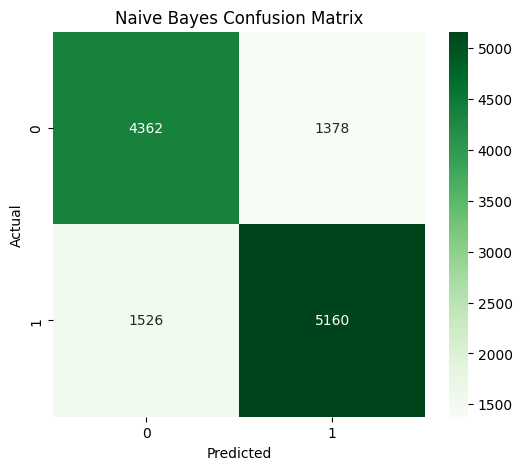

In [ ]:
# NAIVE BAYES CONFUSION MATRIX

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train on TF-IDF vectors
rf_model.fit(X_train_tfidf, y_train)

# Predict
rf_pred = rf_model.predict(X_test_tfidf)

print("Random Forest Training Complete")

Random Forest Training Complete


In [ ]:
# RANDOM FOREST METRICS

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)

print("Precision:", rf_precision)

print("Recall   :", rf_recall)

print("F1 Score :", rf_f1)

print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

Accuracy : 0.8163089560148383
Precision: 0.8201888718734048
Recall   : 0.8249261968938518
F1 Score : 0.8225507135086709

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      7305
           1       0.82      0.82      0.82      7791

    accuracy                           0.82     15096
   macro avg       0.82      0.82      0.82     15096
weighted avg       0.82      0.82      0.82     15096



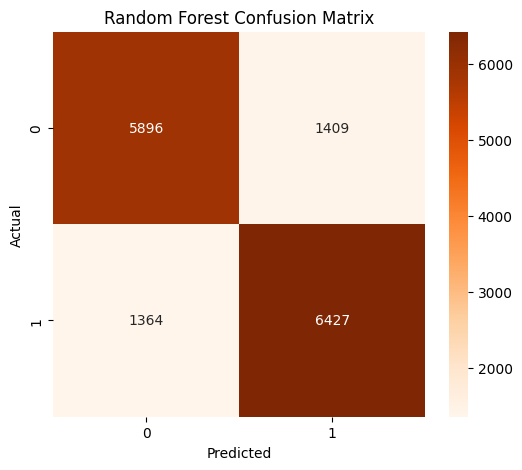

In [ ]:
# RANDOM FOREST CONFUSION MATRIX

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# SUPPORT VECTOR MACHINE (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC()

# Train on TF-IDF vectors
svm_model.fit(X_train_tfidf, y_train)

# Predict
svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Training Complete")

SVM Training Complete


In [ ]:
# SVM METRICS

svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision = precision_score(y_test, svm_pred)

svm_recall = recall_score(y_test, svm_pred)

svm_f1 = f1_score(y_test, svm_pred)

print("Accuracy :", svm_accuracy)

print("Precision:", svm_precision)

print("Recall   :", svm_recall)

print("F1 Score :", svm_f1)

print("\nClassification Report:\n")

print(classification_report(y_test, svm_pred))

Accuracy : 0.8216746157922629
Precision: 0.8165114835505897
Recall   : 0.8441791811064048
F1 Score : 0.8301148554840339

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      7305
           1       0.82      0.84      0.83      7791

    accuracy                           0.82     15096
   macro avg       0.82      0.82      0.82     15096
weighted avg       0.82      0.82      0.82     15096



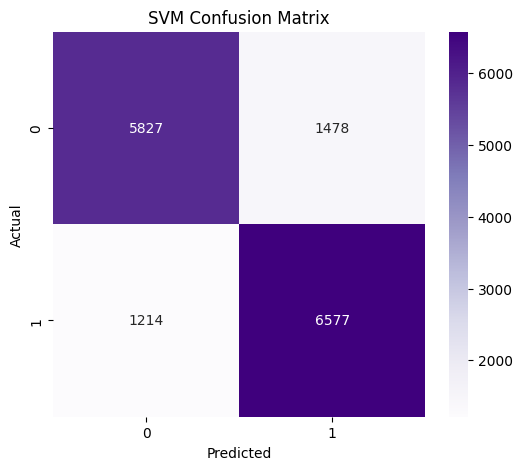

In [ ]:
# SVM CONFUSION MATRIX

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# XGBOOST MODEL

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# Train on TF-IDF vectors
xgb_model.fit(X_train_tfidf, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test_tfidf)

print("XGBoost Training Complete")

XGBoost Training Complete


In [ ]:
# XGBOOST METRICS

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

print("Accuracy :", xgb_accuracy)

print("Precision:", xgb_precision)

print("Recall   :", xgb_recall)

print("F1 Score :", xgb_f1)

print("\nClassification Report:\n")

print(classification_report(y_test, xgb_pred))

Accuracy : 0.8268147432802189
Precision: 0.7961076280041798
Recall   : 0.911606341609333
F1 Score : 0.8499511923023289

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80      5740
         1.0       0.80      0.91      0.85      6686

    accuracy                           0.83     12426
   macro avg       0.84      0.82      0.82     12426
weighted avg       0.83      0.83      0.82     12426



In [ ]:
# MODEL COMPARISON TABLE

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'SVM',
        'XGBoost'
    ],
    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        svm_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        lr_precision,
        nb_precision,
        rf_precision,
        svm_precision,
        xgb_precision
    ],
    'Recall': [
        lr_recall,
        nb_recall,
        rf_recall,
        svm_recall,
        xgb_recall
    ],
    'F1 Score': [
        lr_f1,
        nb_f1,
        rf_f1,
        svm_f1,
        xgb_f1
    ]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.819356,0.812747,0.844564,0.828350
1,Naive Bayes,0.734036,0.756591,0.714542,0.734966
2,Random Forest,0.816309,0.820189,0.824926,0.822551
3,SVM,0.821675,0.816511,0.844179,0.830115
4,XGBoost,0.825782,0.787457,0.907329,0.843154


In [ ]:
# MODEL COMPARISON VISUALIZATION

comparison_melted = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

fig = px.bar(
    comparison_melted,
    x='Model',
    y='Score',
    color='Metric',
    barmode='group',
    title='Model Performance Comparison'
)

fig.show()

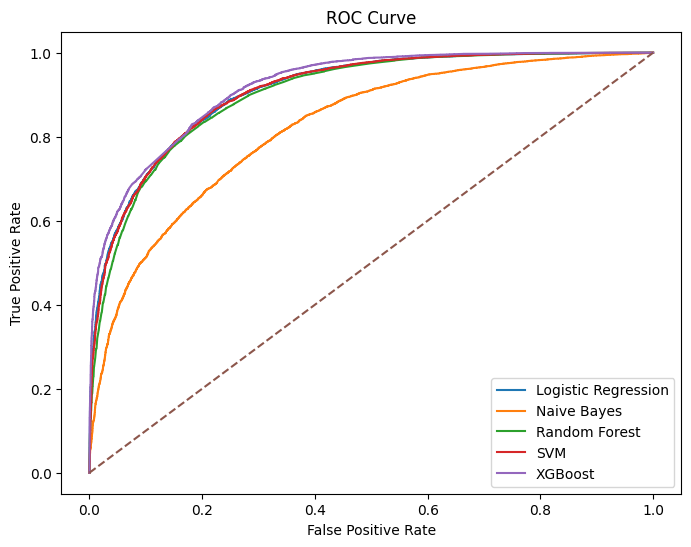

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC CURVE

# Logistic Regression probabilities
lr_probs = lr_model.predict_proba(X_test)[:,1]

# Naive Bayes probabilities
nb_probs = nb_model.predict_proba(X_test)[:,1]

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:,1]

#SVM probabilities
svm_probs = svm_model.decision_function(X_test)

#XGBoost probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')

plt.plot(nb_fpr, nb_tpr, label='Naive Bayes')

plt.plot(rf_fpr, rf_tpr, label='Random Forest')

plt.plot(svm_fpr, svm_tpr, label='SVM')

plt.plot(xgb_fpr, xgb_tpr, label='XGBoost')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
# BEST MODEL

best_model = comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

print("Best Performing Model:")

display(best_model.head(1))

Best Performing Model:


,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.825782,0.787457,0.907329,0.843154


***Hyperparameter Tuning***

In [ ]:
# XGBOOST HYPERPARAMETER TUNING
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid

xgb_params = {

    'n_estimators': [50, 100],

    'max_depth': [4, 6],

    'learning_rate': [0.05, 0.1, 0.3],

    'subsample': [0.7, 0.8, 1.0],

    'colsample_bytree': [0.7, 0.8, 1.0],

    'gamma': [0, 0.1, 0.3]
}

In [ ]:
# TRAIN RANDOM SEARCH

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=5,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

xgb_random.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=4, n_estimators=50, subsample=0.7; total time=  30.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=4, n_estimators=50, subsample=0.7; total time=  28.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=4, n_estimators=50, subsample=0.7; total time=  44.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=50, subsample=0.7; total time=  43.2s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=50, subsample=0.7; total time=  35.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=50, subsample=0.7; total time=  36.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=4, n_estimators=100, subsample=1.0; total time=  56.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.3, max_depth=4, n_e

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=5, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.05, 0.1, 0.3],
                                        'max_depth': [4, 6],
                                        'n_estimators': [50, 100],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
# XGBOOST BEST PARAMETERS
print("Best Parameters:\n")

print(xgb_random.best_params_)

best_xgb = xgb_random.best_estimator_

best_xgb_pred = best_xgb.predict(X_test_tfidf)

Best Parameters:

{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.3, 'gamma': 0, 'colsample_bytree': 0.8}


In [ ]:
# TUNED XGBOOST METRIC RESULTS

best_xgb_accuracy = accuracy_score(
    y_test,
    best_xgb_pred
)

best_xgb_precision = precision_score(
    y_test,
    best_xgb_pred
)

best_xgb_recall = recall_score(
    y_test,
    best_xgb_pred
)

best_xgb_f1 = f1_score(
    y_test,
    best_xgb_pred
)

print("===== Tuned XGBoost Results =====\n")

print("Accuracy :", best_xgb_accuracy)

print("Precision:", best_xgb_precision)

print("Recall   :", best_xgb_recall)

print("F1 Score :", best_xgb_f1)


===== Tuned XGBoost Results =====

Accuracy : 0.8342990503782391
Precision: 0.8074418604651162
Recall   : 0.9087645827101406
F1 Score : 0.8551122369995074


In [ ]:
# TF-IDF VECTORIZING FOR SVM

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# SVM HYPERPARAMETER TUNING
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

svm_params = {
    'C': np.logspace(-3, 2, 20),
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced']
}

svm_random = RandomizedSearchCV(
    LinearSVC(),
    param_distributions=svm_params,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

svm_random.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=LinearSVC(), n_iter=30, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-03, 1.83298071e-03, 3.35981829e-03, 6.15848211e-03,
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02]),
                                        'class_weight': [None, 'balanced'],
                                        'loss': ['hinge', 'squared_hinge']},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
# BEST SVM PARAMETERS
print("===== Best Parameters =====")
print(svm_random.best_params_)

===== Best Parameters =====
{'loss': 'squared_hinge', 'class_weight': None, 'C': np.float64(0.7847599703514607)}


In [ ]:
# TUNED SVM METRIC RESULTS

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

best_svm = svm_random.best_estimator_

y_pred = best_svm.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # binary classification
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("===== Tuned SVM Results =====")
print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1-score : {f1}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred))

===== Tuned SVM Results =====
Accuracy : 0.8598100756478352
Precision: 0.86331569664903
Recall   : 0.8785521986239905
F1-score : 0.8708673091178651

===== Classification Report =====
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      5740
         1.0       0.86      0.88      0.87      6686

    accuracy                           0.86     12426
   macro avg       0.86      0.86      0.86     12426
weighted avg       0.86      0.86      0.86     12426


===== Confusion Matrix =====
[[4810  930]
 [ 812 5874]]


***Constructing Ensemble model***

In [ ]:
# SVM model trained with best parameters
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_model = LinearSVC(
    C=0.7847599703514607,
    loss='squared_hinge',
    class_weight=None
)

# Use Calibrated Classifier SVC to work with probabilities
svm_calibrated = CalibratedClassifierCV(svm_model, cv=3)
svm_calibrated.fit(X_train_tfidf, y_train)

CalibratedClassifierCV(cv=3, estimator=LinearSVC(C=0.7847599703514607))

In [ ]:
# XGBoost model trained with best parameters
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    subsample=1.0,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.3,
    gamma=0,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Ensemble Model
import numpy as np

# probabilities
svm_proba = svm_calibrated.predict_proba(X_test_tfidf)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test_tfidf)[:, 1]

# soft voting
final_proba = (svm_proba + xgb_proba) / 2

# final prediction
y_pred_ensemble = (final_proba >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_ensemble)
precision = precision_score(y_test, y_pred_ensemble)
recall = recall_score(y_test, y_pred_ensemble)
f1 = f1_score(y_test, y_pred_ensemble)

print("===== ENSEMBLE (SVM + XGBoost) =====")
print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1-score : {f1}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred_ensemble))

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred_ensemble))

===== ENSEMBLE (SVM + XGBoost) =====
Accuracy : 0.8631900853050056
Precision: 0.8574706051046745
Recall   : 0.8944062219563267
F1-score : 0.8755490483162518

===== Classification Report =====
              precision    recall  f1-score   support

         0.0       0.87      0.83      0.85      5740
         1.0       0.86      0.89      0.88      6686

    accuracy                           0.86     12426
   macro avg       0.86      0.86      0.86     12426
weighted avg       0.86      0.86      0.86     12426


===== Confusion Matrix =====
[[4746  994]
 [ 706 5980]]


***Model Saving***

Analyzed disagreement analysis

Added weights for combining prediction probabilities from both models:

- 60% XGBoost probability
- 40% SVM probability

In [ ]:
# Analysis of Disagreements

import pandas as pd

comparison = pd.DataFrame({
    "y_true": y_test,
    "svm_pred": svm_calibrated.predict(X_test_tfidf),
    "xgb_pred": xgb_model.predict(X_test_tfidf)
})

# disagreement cases
comparison["agree"] = comparison["svm_pred"] == comparison["xgb_pred"]

different = comparison[comparison["svm_pred"] != comparison["xgb_pred"]]

print("Number of disagreements:", len(different))
print("Total samples:", len(comparison))
print("Disagreement rate:", len(different) / len(comparison))

Number of disagreements: 1782
Total samples: 12426
Disagreement rate: 0.14340898116851764


In [ ]:
xgb_correct = different[
    different["xgb_pred"] == different["y_true"]
]

svm_correct = different[
    different["svm_pred"] == different["y_true"]
]

xgb_correct_pct = (len(xgb_correct) / len(different)) * 100
svm_correct_pct = (len(svm_correct) / len(different)) * 100

print("\n Disagreement Analysis")
print(f"XGBoost correct in disagreements: {xgb_correct_pct:.2f}%")
print(f"SVM correct in disagreements: {svm_correct_pct:.2f}%")

# optional raw counts
print("\nRaw counts:")
print("XGBoost correct:", len(xgb_correct))
print("SVM correct:", len(svm_correct))


 Disagreement Analysis
XGBoost correct in disagreements: 55.50%
SVM correct in disagreements: 44.50%

Raw counts:
XGBoost correct: 989
SVM correct: 793


In [ ]:
import joblib

ensemble_model = {
    "svm": svm_calibrated,
    "xgb": xgb_model,
    "svm_weight": 0.4,
    "xgb_weight": 0.6
}

# save ensemble
joblib.dump(ensemble_model, "model.pkl")

# save vectorizer
joblib.dump(tfidf, "vectorizer.pkl")

print("Models, weights, and vectorizer saved successfully!")

Models, weights, and vectorizer saved successfully!


***Code for app.py***

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
from textblob import TextBlob
import plotly.graph_objects as go
import plotly.express as px
from wordcloud import WordCloud
import re

# ---------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------
st.set_page_config(
    page_title="Fake News AI Pro",
    layout="wide",
    page_icon="🔍"
)

# ---------------------------------------------------
# 2. CUSTOM CSS
# ---------------------------------------------------
st.markdown("""
<style>

/* MAIN BACKGROUND */
.stApp {
    background: linear-gradient(135deg, #1b1338, #24164d, #2d1b69);
    color: #ffffff;
}

/* REMOVE DEFAULT STREAMLIT WHITE SPACE */
.block-container {
    padding-top: 2rem;
    padding-bottom: 2rem;
}

/* MAIN TITLE */
.main-title {
    font-size: 42px;
    font-weight: 800;
    background: linear-gradient(90deg, #c4b5fd, #f9a8d4, #fdba74);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom: 10px;
    text-align: center;
}

/* SUBTITLE */
.subtext {
    text-align: center;
    color: #cbd5e1;
    font-size: 16px;
    margin-bottom: 35px;
}

/* GLASS CARD */
.card {
    background: rgba(30, 41, 59, 0.75);
    border: 1px solid rgba(255,255,255,0.10);
    padding: 22px;
    border-radius: 24px;
    margin-bottom: 20px;
    box-shadow: 0 8px 30px rgba(0,0,0,0.25);
}

/* SECTION HEADER */
.section-header {
    font-size: 13px;
    font-weight: 700;
    color: #d8b4fe;
    text-transform: uppercase;
    letter-spacing: 1px;
    margin-bottom: 14px;
    border-left: 4px solid #c084fc;
    padding-left: 10px;
}

/* INPUTS */
div[data-baseweb="input"] input {
    background-color: #0f172a !important;
    color: white !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 14px !important;
}

div[data-baseweb="textarea"] textarea {
    background-color: #0f172a !important;
    color: white !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 14px !important;
}

/* PLACEHOLDER */
.stTextInput input::placeholder,
.stTextArea textarea::placeholder {
    color: #94a3b8 !important;
}

/* TEXTAREA INSIDE */
textarea {
    background-color: #0f172a !important;
    color: white !important;
}

/* INPUT FOCUS */
.stTextInput input:focus,
.stTextArea textarea:focus {
    border: 1px solid #a855f7 !important;
    box-shadow: 0 0 12px rgba(168,85,247,0.5) !important;
}

/* BUTTON */
.stButton > button {
    width: 100%;
    background: linear-gradient(90deg, #8b5cf6, #c084fc);
    color: white;
    border: none;
    padding: 14px;
    border-radius: 16px;
    font-weight: bold;
    font-size: 15px;
    transition: 0.3s ease;
    margin-top: 10px;
}

.stButton > button:hover {
    transform: translateY(-2px);
    box-shadow: 0 0 20px rgba(192,132,252,0.5);
}

/* METRICS */
[data-testid="metric-container"] {
    background: rgba(255,255,255,0.07);
    border: 1px solid rgba(255,255,255,0.08);
    padding: 12px;
    border-radius: 18px;
}

/* TEXT COLORS */
h1, h2, h3, h4, h5, h6, p, label {
    color: white !important;
}

/* INFO BOX */
.stAlert {
    background-color: rgba(255,255,255,0.08) !important;
    border-radius: 18px !important;
    border: 1px solid rgba(255,255,255,0.1) !important;
    color: white !important;
}

/* CONFIDENCE TEXT */
.confidence-text {
    font-size: 15px;
    font-weight: 500;
    color: #cbd5e1;
    margin-top: -10px;
}

/* SCROLLBAR */
::-webkit-scrollbar {
    width: 8px;
}

::-webkit-scrollbar-thumb {
    background: #7c3aed;
    border-radius: 20px;
}

</style>
""", unsafe_allow_html=True)

# ---------------------------------------------------
# 3. LOAD MODELS
# ---------------------------------------------------
@st.cache_resource
def load_all():
    try:
        return joblib.load("model.pkl"), joblib.load("vectorizer.pkl")
    except:
        return None, None

data, tfidf = load_all()

# ---------------------------------------------------
# 4. HEADER
# ---------------------------------------------------
st.markdown(
    '<div class="main-title">Fake News Integrity Checker 🔍</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtext">AI-powered fake news detection, sentiment analysis & explainable insights.</div>',
    unsafe_allow_html=True
)

# ---------------------------------------------------
# 5. LAYOUT
# ---------------------------------------------------
col1, col2 = st.columns([1, 1.3], gap="large")

# ---------------------------------------------------
# LEFT SIDE
# ---------------------------------------------------
with col1:

    st.markdown('<div class="card">', unsafe_allow_html=True)

    st.markdown(
        '<p class="section-header">1. Content Input</p>',
        unsafe_allow_html=True
    )

    headline = st.text_input("Headline (Optional)")
    txt = st.text_area(
        "Paste news article text here...",
        height=320
    )

    btn = st.button("RUN DEEP ANALYSIS")

    st.markdown('</div>', unsafe_allow_html=True)

    # WORD IMPORTANCE
    if btn and txt and tfidf:

        st.markdown('<div class="card">', unsafe_allow_html=True)

        st.markdown(
            '<p class="section-header">4. Word Importance (Explainable AI)</p>',
            unsafe_allow_html=True
        )

        features = tfidf.get_feature_names_out()
        matrix = tfidf.transform([txt]).toarray()[0]
        top_indices = matrix.argsort()[-10:][::-1]

        impact_data = [
            {"Word": features[i], "Weight": matrix[i]}
            for i in top_indices if matrix[i] > 0
        ]

        if impact_data:

            df_imp = pd.DataFrame(impact_data).sort_values(
                by="Weight",
                ascending=True
            )

            fig_bar = px.bar(
                df_imp,
                x="Weight",
                y="Word",
                orientation='h',
                color='Weight',
                color_continuous_scale='Purples'
            )

            fig_bar.update_layout(
                height=340,
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(0,0,0,0)',
                font_color='white',
                margin=dict(t=0, b=0, l=0, r=10),
                coloraxis_showscale=False
            )

            st.plotly_chart(fig_bar, use_container_width=True)

        st.markdown('</div>', unsafe_allow_html=True)

# ---------------------------------------------------
# RIGHT SIDE
# ---------------------------------------------------
with col2:

    st.markdown(
        '<p class="section-header">Analysis & Insights</p>',
        unsafe_allow_html=True
    )

    if btn and txt and data:

        # MODEL PREDICTION
        vec = tfidf.transform([txt])

        p_real = (
            0.4 * data["svm"].predict_proba(vec)[0][1] +
            0.6 * data["xgb"].predict_proba(vec)[0][1]
        )

        # LOGIC
        if p_real >= 0.5:
            label = "REAL"
            conf = int(p_real * 100)
            color = "#16a34a"
        else:
            label = "FAKE"
            conf = int((1 - p_real) * 100)
            color = "#dc2626"

        # CONFIDENCE LEVEL
        if conf >= 90:
            level_text = "🟢 High Confidence"
        elif conf >= 70:
            level_text = "🟡 Medium Confidence"
        else:
            level_text = "🟠 Low Confidence (Uncertain)"

        # VERDICT CARD
        st.markdown(f"""
        <div class="card">
            <p class="section-header">Verdict</p>
            <h2 style="color:{color}; margin-bottom:5px;">
                {conf}% CONFIDENCE: {label}
            </h2>
            <p class="confidence-text">
                Status: {level_text}
            </p>
        </div>
        """, unsafe_allow_html=True)

        # GAUGE CHART
        fig_g = go.Figure(go.Indicator(
            mode="gauge+number",
            value=conf,
            gauge={
                'axis': {'range': [0, 100]},
                'bar': {'color': color}
            }
        ))

        fig_g.update_layout(
            height=200,
            margin=dict(t=0, b=0),
            paper_bgcolor='rgba(0,0,0,0)',
            font={'color': "white"}
        )

        st.plotly_chart(fig_g, use_container_width=True)

        # SENTIMENT + STYLE
        c_a, c_b = st.columns(2)

        with c_a:

            pol = TextBlob(txt).sentiment.polarity

            st.markdown(f"""
            <div class="card">
                <p class="section-header">Sentiment</p>
                <h3>{pol:.2f}</h3>
                <p style="font-size:11px;">
                    Emotional Tone
                </p>
            </div>
            """, unsafe_allow_html=True)

        with c_b:

            words = txt.split()

            caps = len([
                w for w in words if w.isupper()
            ]) / (len(words)+1)

            st.markdown(f"""
            <div class="card">
                <p class="section-header">Style</p>
                <h3>{caps:.1%}</h3>
                <p style="font-size:11px;">
                    Caps Lock Ratio
                </p>
            </div>
            """, unsafe_allow_html=True)

        # TEXT STATISTICS
        st.markdown('<div class="card">', unsafe_allow_html=True)

        st.markdown(
            '<p class="section-header">5. Text Statistics</p>',
            unsafe_allow_html=True
        )

        s1, s2, s3 = st.columns(3)

        s1.metric("Word Count", len(words))
        s2.metric("Char Count", len(txt))
        s3.metric(
            "Sentences",
            len(re.findall(r'[.!?]+', txt)) + 1
        )

        st.markdown('</div>', unsafe_allow_html=True)

        # WORDCLOUD (UNCHANGED)
        st.markdown(
            '<p class="section-header">6. Top Keywords Wordcloud</p>',
            unsafe_allow_html=True
        )

        wc_scheme = "Reds" if label == "FAKE" else "Greens"

        wc = WordCloud(
            width=800,
            height=300,
            background_color="white",
            colormap=wc_scheme
        ).generate(txt.lower())

        st.image(wc.to_array(), use_container_width=True)

    else:
        st.info("Input content and click analysis to start")

Overwriting app.py


***Code for deploy***

In [ ]:
# =========================================
# 1. УБИТЬ СТАРЫЕ ПРОЦЕССЫ
# =========================================
!pkill -f streamlit
!pkill -f cloudflared

import time
time.sleep(2)

# =========================================
# 2. УСТАНОВИТЬ ЗАВИСИМОСТИ
# =========================================
!pip install -q streamlit textblob plotly wordcloud joblib

# cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# =========================================
# 3. ЗАПУСТИТЬ STREAMLIT
# =========================================
!nohup streamlit run app.py \
    --server.port 8501 \
    --server.headless true \
    --browser.serverAddress 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > streamlit.log 2>&1 &

# =========================================
# 4. ДОЖДАТЬСЯ ЗАПУСКА
# =========================================
import requests

ready = False

for i in range(40):
    try:
        r = requests.get("http://localhost:8501")
        if r.status_code == 200:
            ready = True
            print("✅ Streamlit успешно запущен")
            break
    except:
        pass

    time.sleep(2)

if not ready:
    print("❌ Streamlit НЕ запустился")
    !tail -30 streamlit.log

# =========================================
# 5. ЗАПУСТИТЬ CLOUDFLARED
# =========================================
!nohup ./cloudflared tunnel --url http://localhost:8501 > tunnel.log 2>&1 &

# =========================================
# 6. ПОЛУЧИТЬ ССЫЛКУ
# =========================================
import re
import time

public_url = None

for _ in range(30):

    time.sleep(2)

    try:
        log = open("tunnel.log", "r").read()

        match = re.findall(
            r"https://[-0-9a-z]+\.trycloudflare\.com",
            log
        )

        if match:
            public_url = match[0]
            break

    except:
        pass

if public_url:
    print("\n🌐 STREAMLIT URL:")
    print(public_url)
else:
    print("❌ Tunnel URL not found")
    !tail -20 tunnel.log

✅ Streamlit успешно запущен

🌐 STREAMLIT URL:
https://intl-forward-assess-bunch.trycloudflare.com
